# 05 -- Results & Evaluation


## Objectives
1. Compile and compare all model results
2. Generate confusion matrices for classification
3. Analyze feature importance from best models
4. Visualize K-Means clusters via PCA
5. Produce final business insights and recommendations

In [1]:
# ── Imports & Environment Setup ──
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import findspark

os.environ['HADOOP_HOME'] = r'A:\hadoop'
os.environ['SPARK_HOME'] = r'A:\spark'
os.environ['PATH'] = r'A:\hadoop\bin;' + os.environ.get('PATH', '')
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.regression import (
    LinearRegressionModel, RandomForestRegressionModel, GBTRegressionModel
)
from pyspark.ml.classification import RandomForestClassificationModel
from pyspark.ml.clustering import KMeansModel
from pyspark.ml import Pipeline

plt.style.use('seaborn-v0_8-darkgrid')
matplotlib.rcParams.update({'font.size': 12, 'figure.figsize': (12, 7), 'figure.dpi': 150})

OUTPUT_DIR = os.path.join("outputs")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")

spark = (
    SparkSession.builder
    .appName("IMDb_Evaluation")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} ready.")

Spark 3.5.1 ready.


## 1. Regression Results Comparison

In [2]:
# ── Load regression results ──
reg_df = pd.read_csv(os.path.join(RESULTS_DIR, "regression_results.csv"))

print("="*80)
print("REGRESSION MODEL COMPARISON")
print("="*80)
print(reg_df.to_string(index=False))

# Highlight best model
best_reg = reg_df.loc[reg_df['test_r2'].idxmax()]
print(f"\n Best Regression Model: {best_reg['model']}")
print(f"   Test R²: {best_reg['test_r2']:.4f}, Test RMSE: {best_reg['test_rmse']:.4f}")

REGRESSION MODEL COMPARISON
                  model  train_rmse  train_mae  train_r2  val_rmse  val_mae  val_r2  test_rmse  test_mae  test_r2
      Linear Regression      0.5917     0.4366    0.7921    0.5926   0.4361  0.7907     0.5937    0.4376   0.7932
Decision Tree Regressor      0.5314     0.3783    0.8323    0.5563   0.3925  0.8155     0.5603    0.3965   0.8157
Random Forest Regressor      0.4715     0.3358    0.8680    0.5125   0.3605  0.8434     0.5173    0.3640   0.8430
          GBT Regressor      0.4534     0.3281    0.8779    0.5059   0.3591  0.8474     0.5137    0.3627   0.8452

 Best Regression Model: GBT Regressor
   Test R²: 0.8452, Test RMSE: 0.5137


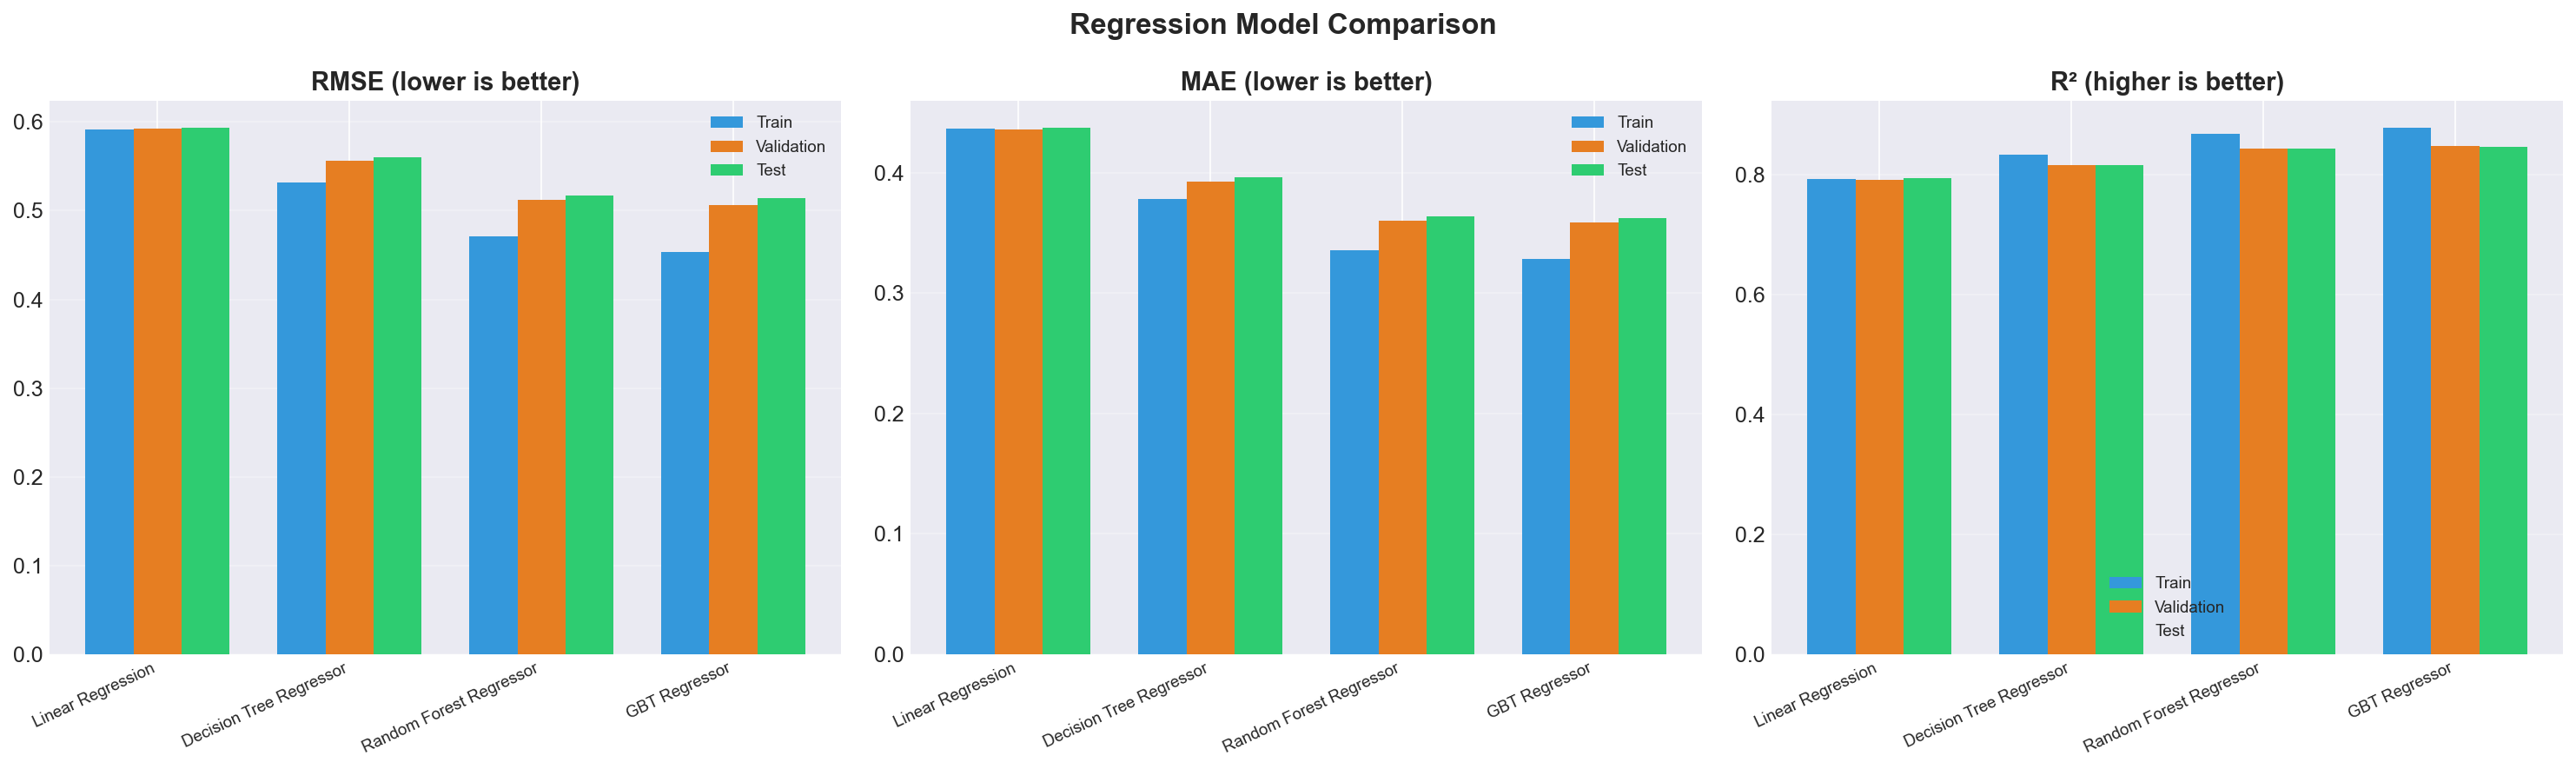

In [3]:
# ── Visualization: Regression model comparison ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (metric, title) in enumerate([
    ('rmse', 'RMSE (lower is better)'),
    ('mae', 'MAE (lower is better)'),
    ('r2', 'R² (higher is better)')
]):
    ax = axes[idx]
    x = range(len(reg_df))
    width = 0.25
    ax.bar([i - width for i in x], reg_df[f'train_{metric}'], width, label='Train', color='#3498db')
    ax.bar(x, reg_df[f'val_{metric}'], width, label='Validation', color='#e67e22')
    ax.bar([i + width for i in x], reg_df[f'test_{metric}'], width, label='Test', color='#2ecc71')
    ax.set_xticks(x)
    ax.set_xticklabels(reg_df['model'], rotation=25, ha='right', fontsize=9)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Regression Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '12_regression_comparison.png'))
plt.show()

## 2. Classification Results Comparison

In [4]:
# ── Load classification results ──
cls_df = pd.read_csv(os.path.join(RESULTS_DIR, "classification_results.csv"))

print("="*80)
print("CLASSIFICATION MODEL COMPARISON")
print("="*80)
print(cls_df.to_string(index=False))

best_cls = cls_df.loc[cls_df['test_f1'].idxmax()]
print(f"\n Best Classification Model: {best_cls['model']}")
print(f"   Test Accuracy: {best_cls['test_accuracy']:.4f}, Test F1: {best_cls['test_f1']:.4f}")

CLASSIFICATION MODEL COMPARISON
                   model  train_accuracy  train_f1  train_precision  train_recall  val_accuracy  val_f1  val_precision  val_recall  test_accuracy  test_f1  test_precision  test_recall
     Logistic Regression          0.8071    0.8057           0.8079        0.8071        0.8070  0.8055         0.8082      0.8070         0.8068   0.8054          0.8078       0.8068
Decision Tree Classifier          0.8387    0.8370           0.8417        0.8387        0.8289  0.8271         0.8318      0.8289         0.8299   0.8279          0.8334       0.8299
Random Forest Classifier          0.8604    0.8585           0.8661        0.8604        0.8436  0.8415         0.8489      0.8436         0.8404   0.8382          0.8458       0.8404

 Best Classification Model: Random Forest Classifier
   Test Accuracy: 0.8404, Test F1: 0.8382


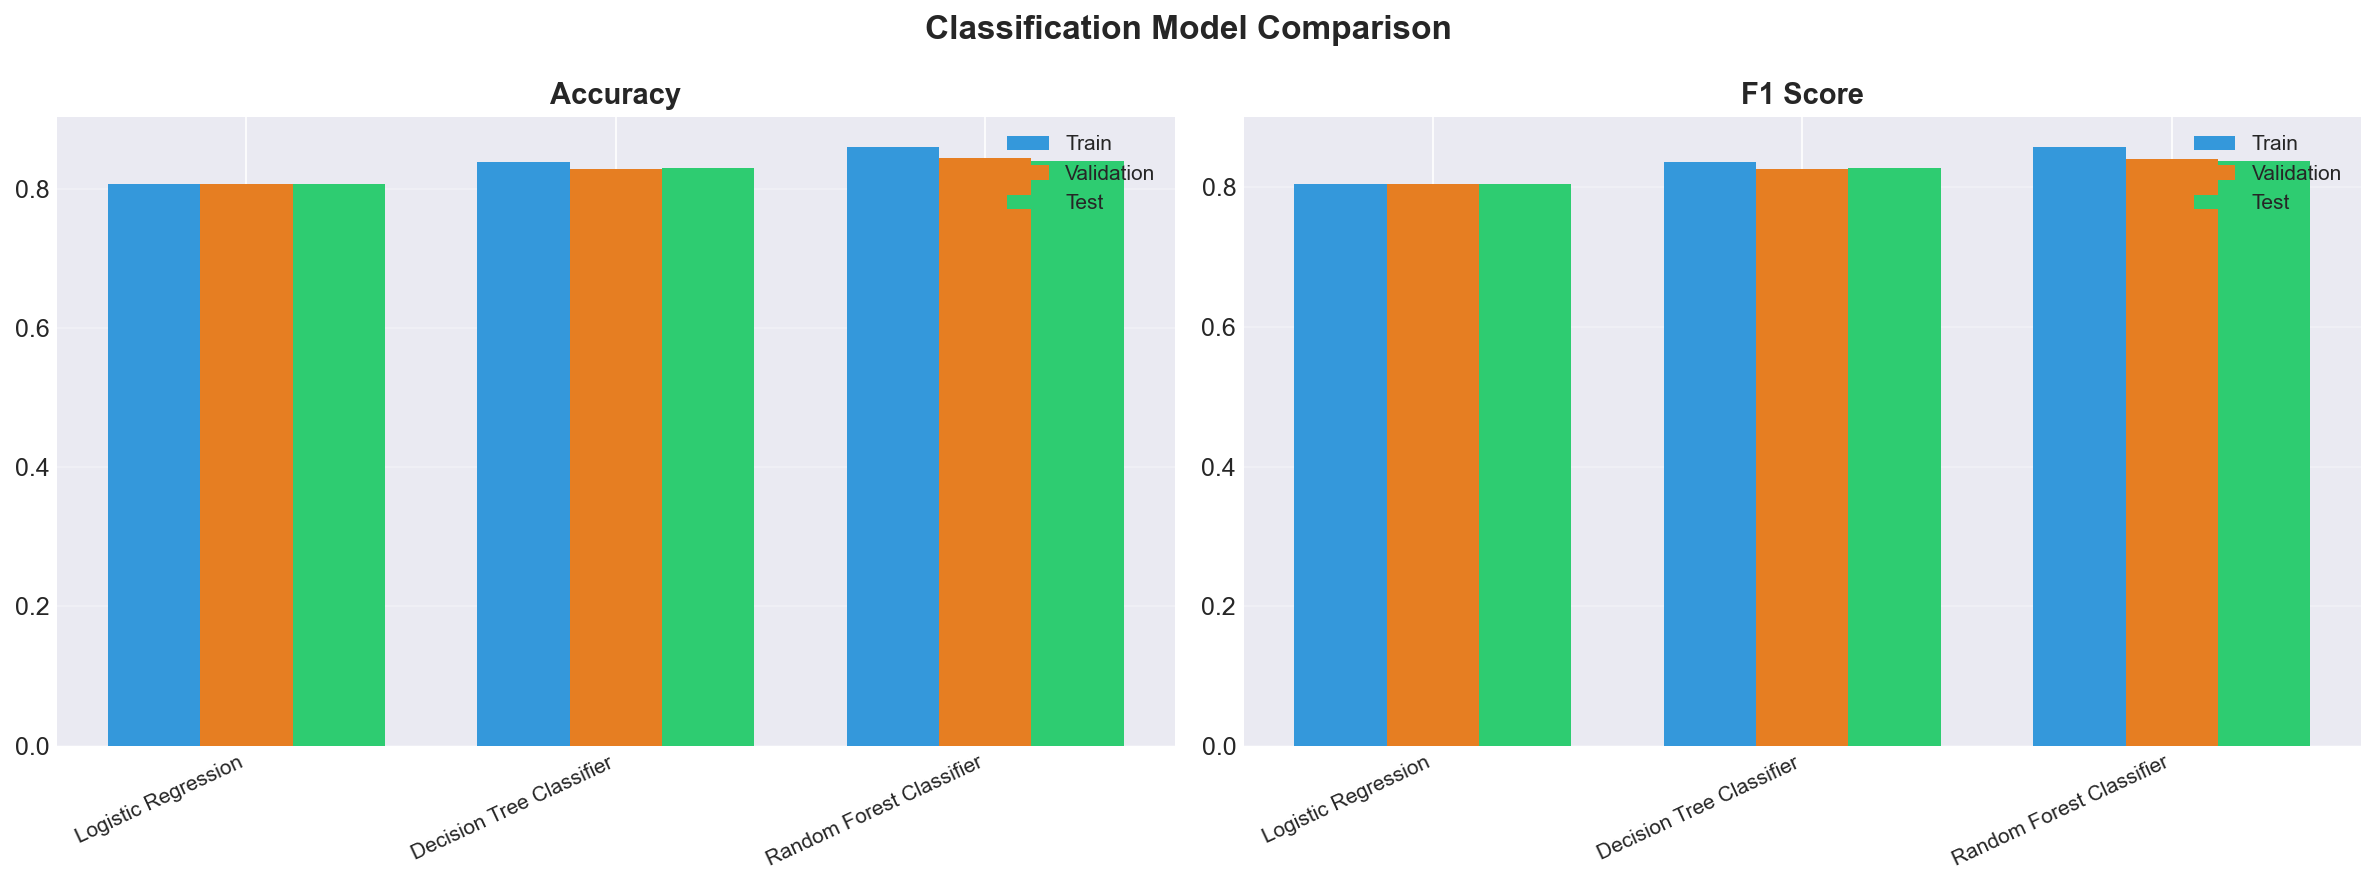

In [5]:
# ── Visualization: Classification model comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (metric, title) in enumerate([
    ('accuracy', 'Accuracy'),
    ('f1', 'F1 Score')
]):
    ax = axes[idx]
    x = range(len(cls_df))
    width = 0.25
    ax.bar([i - width for i in x], cls_df[f'train_{metric}'], width, label='Train', color='#3498db')
    ax.bar(x, cls_df[f'val_{metric}'], width, label='Validation', color='#e67e22')
    ax.bar([i + width for i in x], cls_df[f'test_{metric}'], width, label='Test', color='#2ecc71')
    ax.set_xticks(x)
    ax.set_xticklabels(cls_df['model'], rotation=25, ha='right', fontsize=10)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Classification Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '13_classification_comparison.png'))
plt.show()

## 3. Confusion Matrix (Best Classifier)

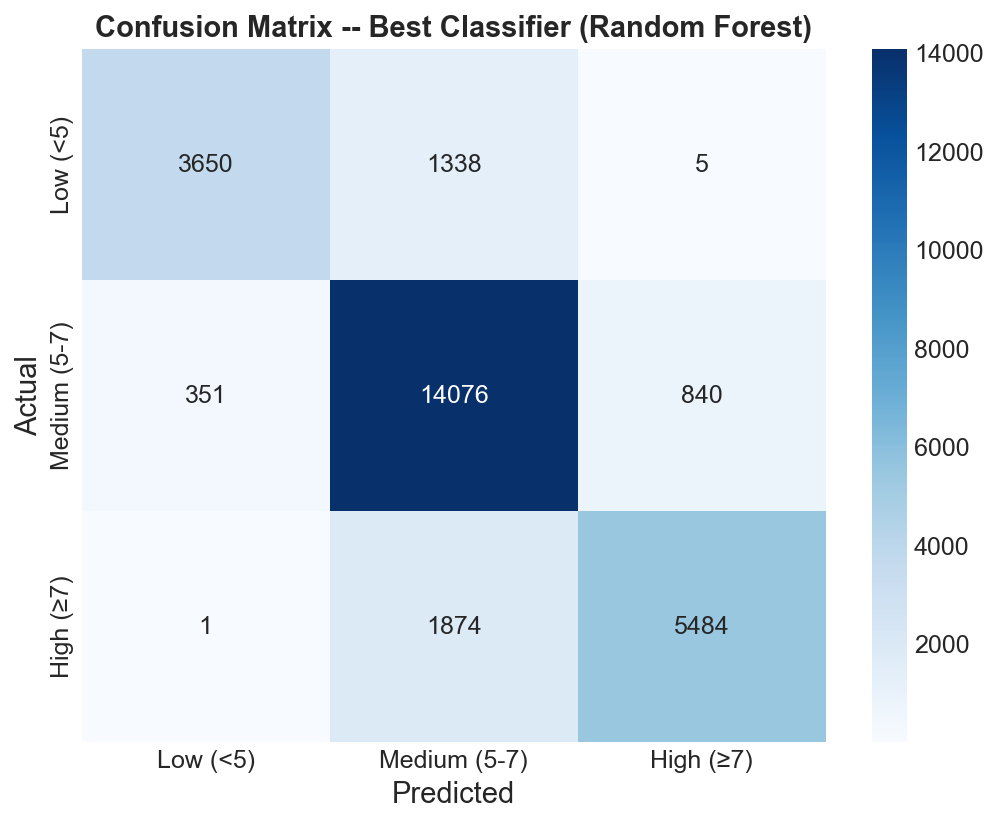

In [6]:
# ── Load best classifier and test data ──
with open(os.path.join(OUTPUT_DIR, "feature_columns.json")) as f:
    feat_meta = json.load(f)

df = spark.read.parquet(os.path.join(OUTPUT_DIR, "parquet", "features"))
feature_cols = feat_meta['all_feature_cols']
df = df.dropna(subset=feature_cols + ['averageRating', 'ratingTier'])

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw", handleInvalid="skip")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
pipeline = Pipeline(stages=[assembler, scaler])
pipeline_model = pipeline.fit(df)
df_ml = pipeline_model.transform(df)
df_ml = df_ml.withColumnRenamed("averageRating", "label_reg")
df_ml = df_ml.withColumnRenamed("ratingTier", "label_cls")

_, _, test_df = df_ml.randomSplit([0.70, 0.15, 0.15], seed=42)

# Load best classifier (RF)
rf_cls = RandomForestClassificationModel.load(os.path.join(MODELS_DIR, "rf_classifier"))
preds = rf_cls.transform(test_df)

# Build confusion matrix
cm_data = (
    preds.groupBy("label_cls", "prediction")
    .count()
    .toPandas()
)

labels = [0, 1, 2]
cm = np.zeros((3, 3), dtype=int)
for _, row in cm_data.iterrows():
    cm[int(row['label_cls']), int(row['prediction'])] = int(row['count'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low (<5)', 'Medium (5-7)', 'High (≥7)'],
            yticklabels=['Low (<5)', 'Medium (5-7)', 'High (≥7)'],
            ax=ax)
ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('Actual', fontsize=14)
ax.set_title('Confusion Matrix -- Best Classifier (Random Forest)', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(PLOTS_DIR, '14_confusion_matrix.png'))
plt.show()

## 4. Feature Importance (Random Forest)

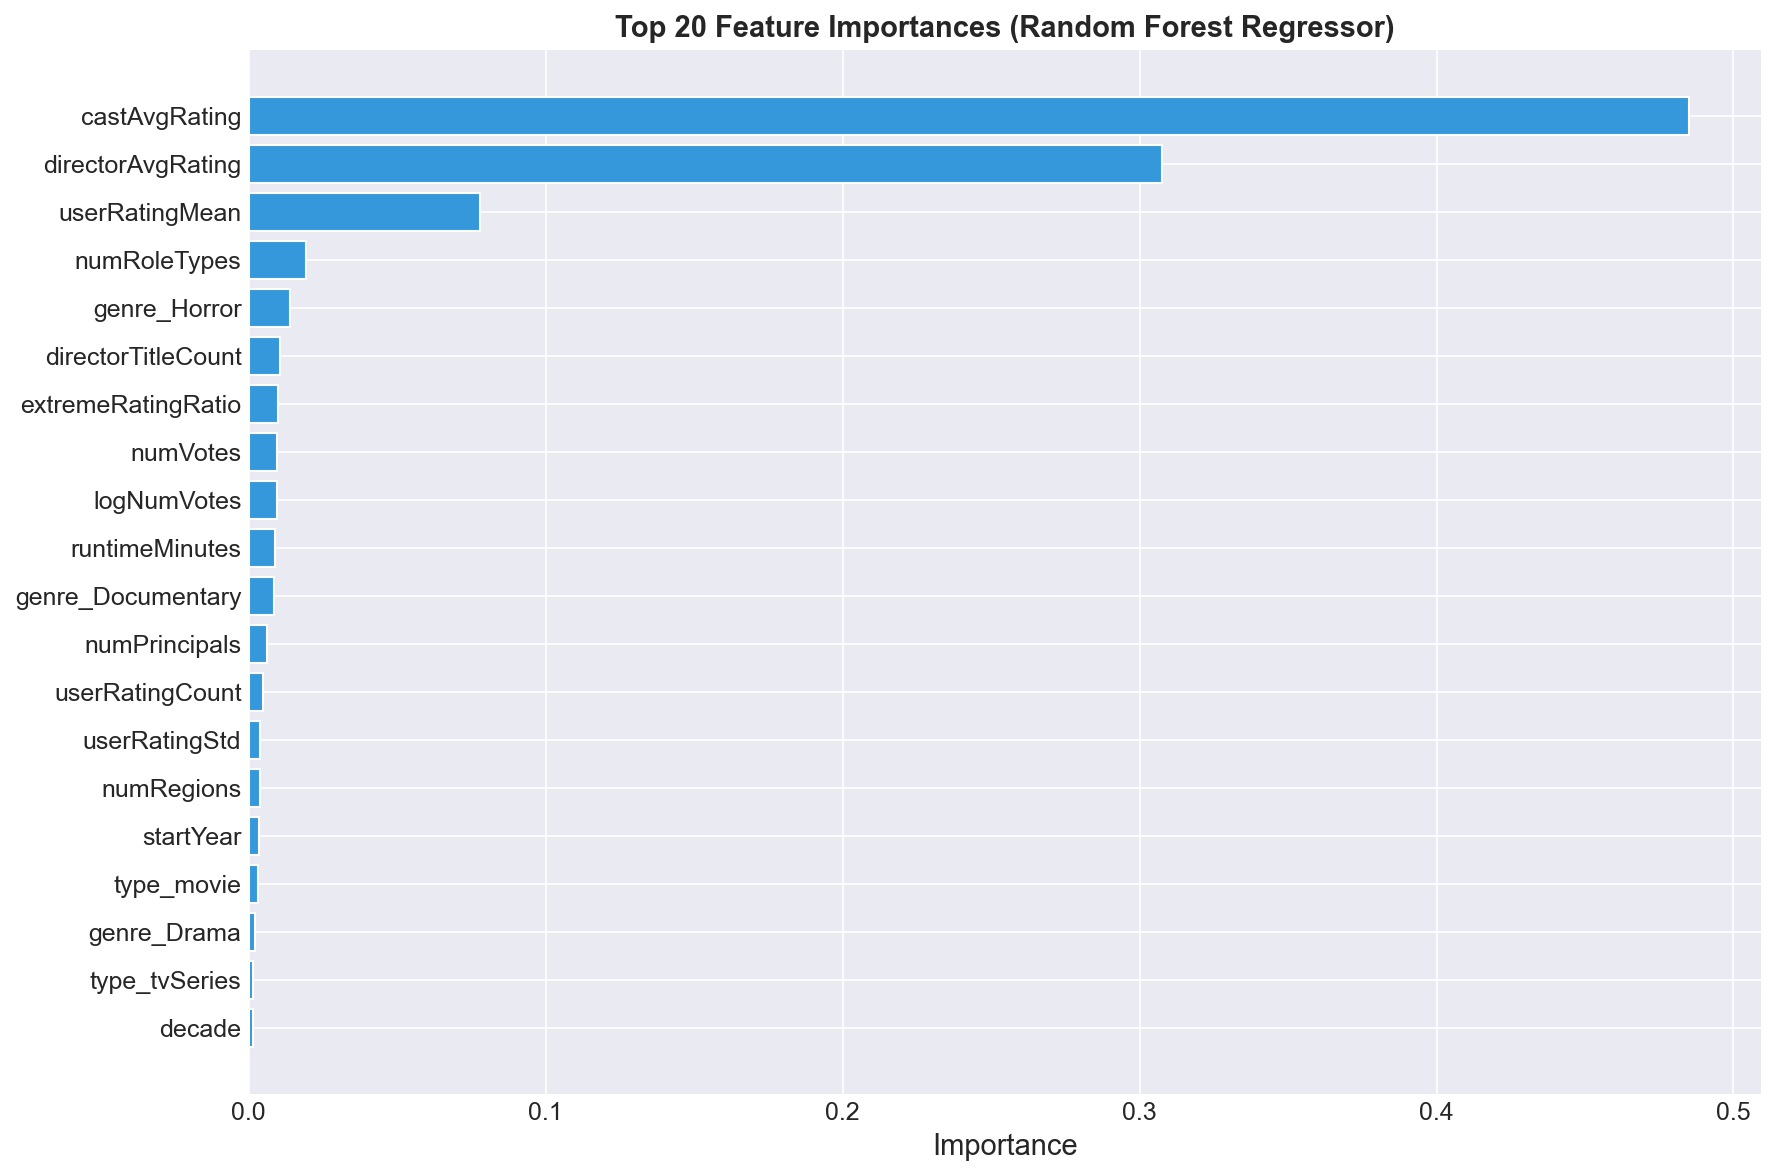


Top 10 Features:
           feature  importance
     castAvgRating    0.485025
 directorAvgRating    0.307564
    userRatingMean    0.077723
      numRoleTypes    0.019431
      genre_Horror    0.013788
directorTitleCount    0.010568
extremeRatingRatio    0.009744
          numVotes    0.009617
       logNumVotes    0.009583
    runtimeMinutes    0.008792


In [7]:
# ── Feature importance from best RF regressor ──
rf_reg = RandomForestRegressionModel.load(os.path.join(MODELS_DIR, "rf_regressor"))
importances = rf_reg.featureImportances.toArray()

feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 20
top_n = feat_imp.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(top_n)), top_n['importance'], color='#3498db', edgecolor='white')
ax.set_yticks(range(len(top_n)))
ax.set_yticklabels(top_n['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance', fontsize=14)
ax.set_title('Top 20 Feature Importances (Random Forest Regressor)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '15_feature_importance.png'))
plt.show()

print("\nTop 10 Features:")
print(feat_imp.head(10).to_string(index=False))

## 5. K-Means Cluster Visualization (PCA)

In [9]:
# ── Load K-Means model and apply PCA ──
kmeans = KMeansModel.load(os.path.join(MODELS_DIR, "kmeans"))

# Apply PCA to full dataset for visualization
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(df_ml)
df_pca = pca_model.transform(df_ml)

# Make predictions
df_clustered = kmeans.transform(df_pca).select(
    "pca_features", "prediction", "label_reg"
)

print(f"K-Means clustering applied. Total rows: {df_clustered.count():,}")

K-Means clustering applied. Total rows: 186,201


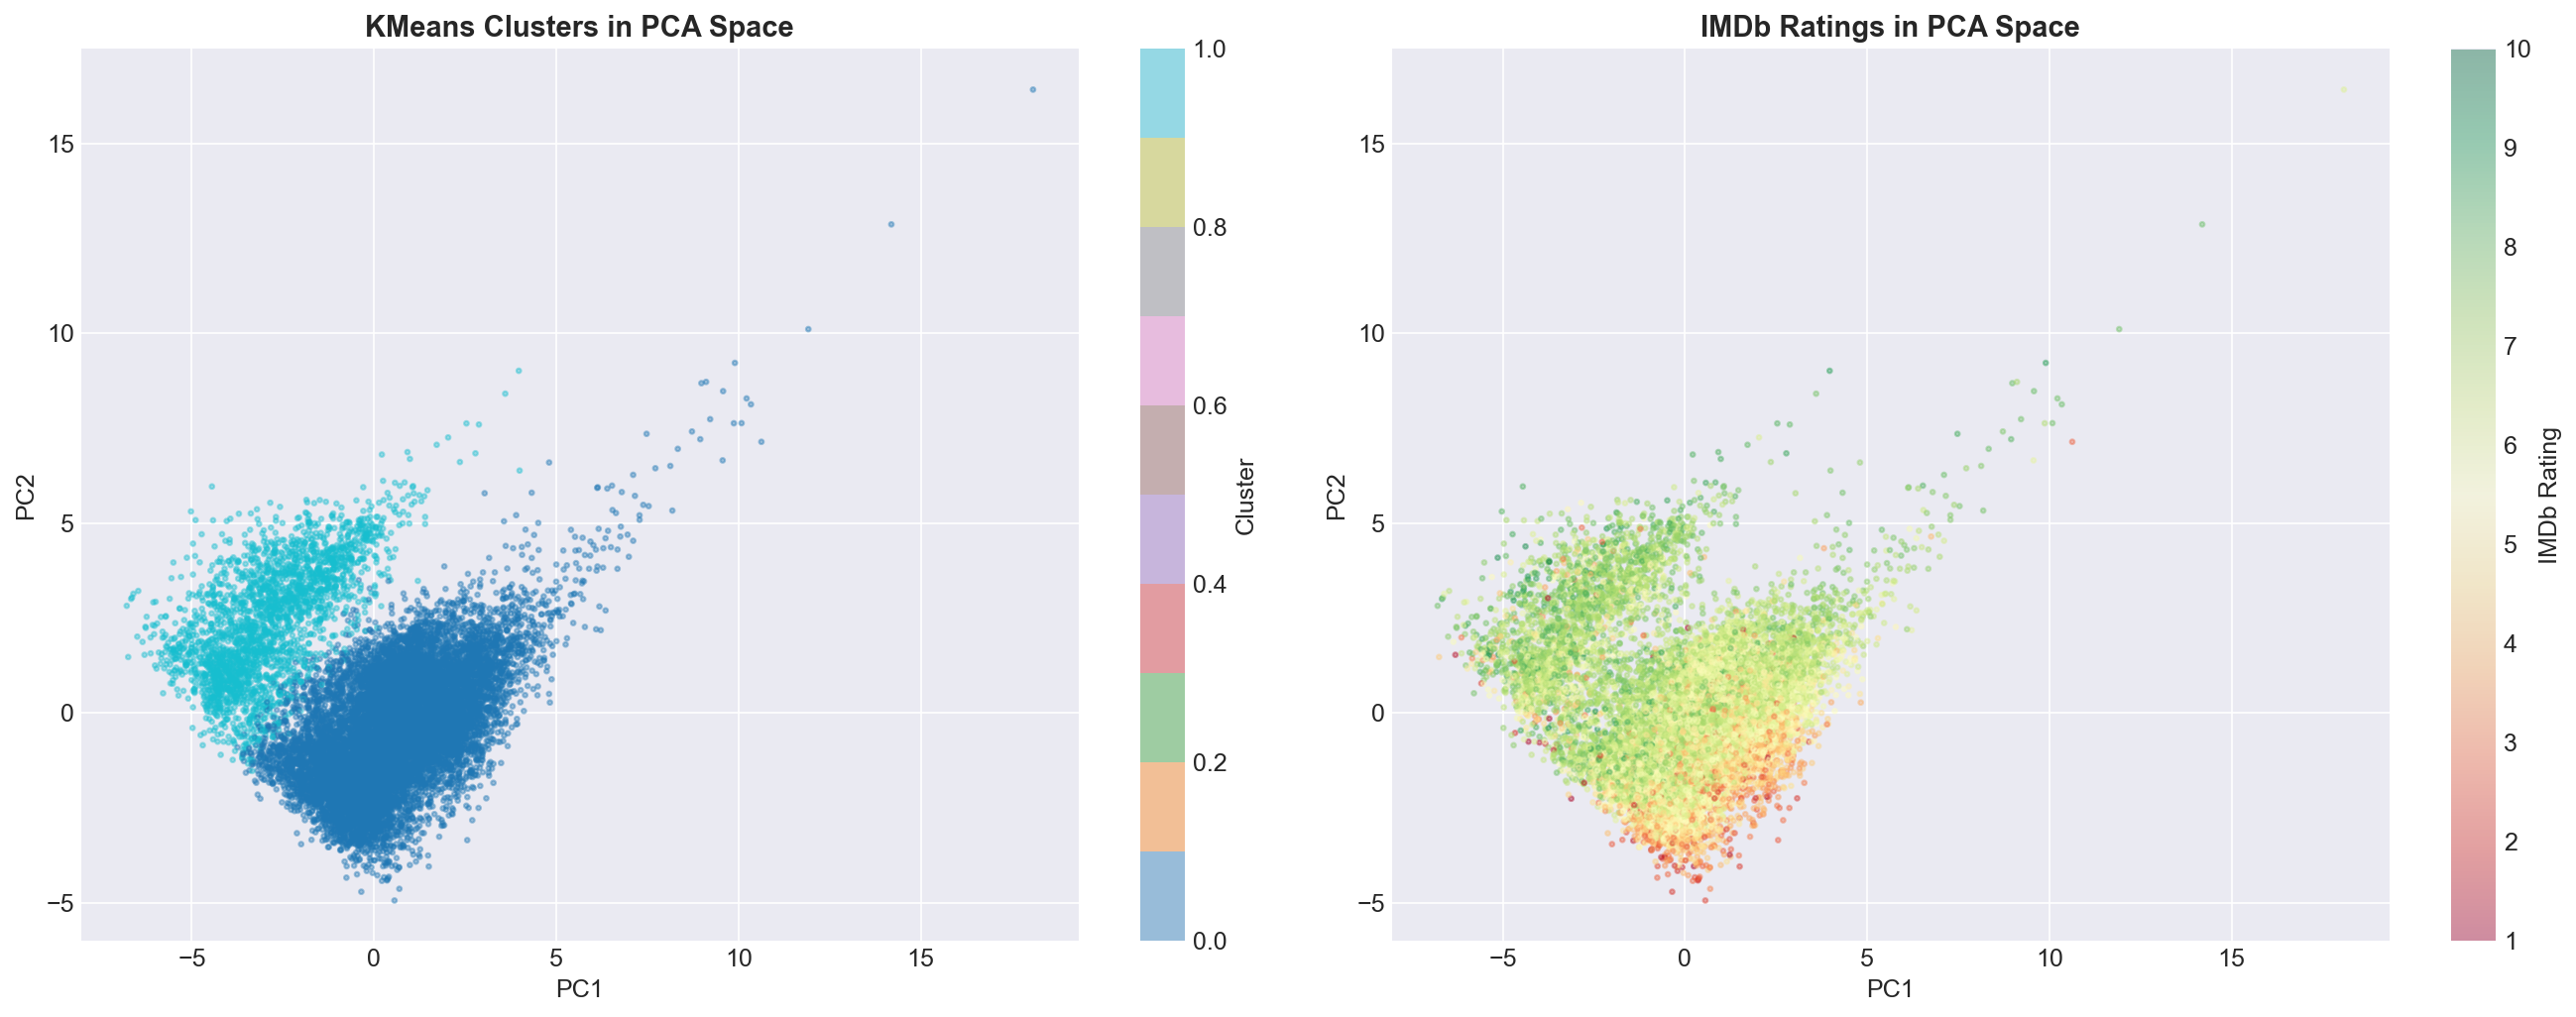

PCA visualization generated (15,000 sampled points)


In [10]:
# --- PCA Cluster Visualization ---
sample_pdf = (
    df_clustered
    .select("pca_features", "prediction", "label_reg")
    .sample(fraction=0.3, seed=42)
    .limit(15000)
    .toPandas()
)

coords = np.array(sample_pdf['pca_features'].tolist())
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Cluster coloring
sc1 = axes[0].scatter(coords[:, 0], coords[:, 1],
                      c=sample_pdf['prediction'], cmap='tab10', s=5, alpha=0.4)
plt.colorbar(sc1, ax=axes[0], label='Cluster')
axes[0].set_title('KMeans Clusters in PCA Space', fontsize=14, fontweight='bold')

# Right: Regression label coloring
sc2 = axes[1].scatter(coords[:, 0], coords[:, 1],
                      c=sample_pdf['label_reg'], cmap='RdYlGn', s=5, alpha=0.4,
                      vmin=1, vmax=10)
plt.colorbar(sc2, ax=axes[1], label='IMDb Rating')
axes[1].set_title('IMDb Ratings in PCA Space', fontsize=14, fontweight='bold')

for ax in axes:
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'cluster_pca_viz.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f"PCA visualization generated ({len(sample_pdf):,} sampled points)")


In [12]:
print("All plots saved to outputs/plots/")
print("All models saved to outputs/models/")
spark.stop()
print("Spark session stopped.")

All plots saved to outputs/plots/
All models saved to outputs/models/
Spark session stopped.
